# Clasificacion de Malformacion de Arnold-Chiari Tipo I
## Notebook 02 — Submuestreo, Recorte y Preprocesamiento

Construye el dataset balanceado y aplica la pipeline de preprocesamiento.

| Etapa           | Detalle                                          |
|-----------------|--------------------------------------------------|
| Submuestreo     | 30 Chiari + 30 Normal (semilla fija = 42)        |
| Val. externa    | 96 Chiari restantes → `data/val_externo/`        |
| Recorte         | Fosa posterior, coordenadas ajustables por clase |
| Normalizacion   | Clip percentil 1-99 + CLAHE                      |
| Split           | 70% train · 15% val · 15% test (estratificado)  |
| Augmentation    | x5 solo en train                                 |

In [1]:
import json, shutil, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from tqdm.auto import tqdm
from skimage.util import random_noise
from skimage import transform as sk_transform
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

BASE = Path('.').resolve()

DIR_RAW_CH   = BASE / 'data' / 'raw'      / 'chiari'
DIR_RAW_NO   = BASE / 'data' / 'raw'      / 'normal'
DIR_BAL_CH   = BASE / 'data' / 'balanced' / 'chiari'
DIR_BAL_NO   = BASE / 'data' / 'balanced' / 'normal'
DIR_CRP_CH   = BASE / 'data' / 'cropped'  / 'chiari'
DIR_CRP_NO   = BASE / 'data' / 'cropped'  / 'normal'
DIR_VAL_EXT  = BASE / 'data' / 'val_externo'
DIR_PROC     = BASE / 'data' / 'processed'
DIR_REPORTS  = BASE / 'reports'
DIR_FIGURES  = BASE / 'reports' / 'figures'

for d in [DIR_BAL_CH, DIR_BAL_NO, DIR_CRP_CH, DIR_CRP_NO, DIR_VAL_EXT,
          DIR_REPORTS, DIR_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

SEED        = 42
N_POR_CLASE = 30
IMG_SIZE    = (224, 224)
EXTENSIONES = {'.jpg', '.jpeg', '.png'}

random.seed(SEED)
np.random.seed(SEED)

def listar(carpeta):
    imgs = []
    for ext in EXTENSIONES:
        imgs += list(Path(carpeta).glob(f'*{ext}'))
        imgs += list(Path(carpeta).glob(f'*{ext.upper()}'))
    return sorted(set(imgs))

chiari_raw = listar(DIR_RAW_CH)
normal_raw = listar(DIR_RAW_NO)
print(f'Disponibles — Chiari: {len(chiari_raw)}  |  Normal: {len(normal_raw)}')

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Disponibles — Chiari: 126  |  Normal: 30


## 1. Submuestreo estratificado

In [ ]:
"""
random.seed(SEED)

# Seleccion aleatoria simetrica (semilla fija para reproducibilidad)
seleccion_ch = sorted(random.sample(chiari_raw, min(N_POR_CLASE, len(chiari_raw))))
seleccion_no = sorted(random.sample(normal_raw, min(N_POR_CLASE, len(normal_raw))))
restantes_ch = [p for p in chiari_raw if p not in set(seleccion_ch)]

# Limpiar destinos y copiar
for dst_dir, fuentes in [
    (DIR_BAL_CH,  seleccion_ch),
    (DIR_BAL_NO,  seleccion_no),
    (DIR_VAL_EXT, restantes_ch),
]:
    for f in dst_dir.iterdir():
        f.unlink()
    for src in fuentes:
        shutil.copy2(src, dst_dir / src.name)

# Manifiesto de trazabilidad
registros = (
    [{'archivo': p.name, 'clase': 'chiari', 'set': 'balanced', 'seed': SEED}
     for p in seleccion_ch] +
    [{'archivo': p.name, 'clase': 'normal',  'set': 'balanced', 'seed': SEED}
     for p in seleccion_no] +
    [{'archivo': p.name, 'clase': 'chiari', 'set': 'val_externo', 'seed': SEED}
     for p in restantes_ch]
)
pd.DataFrame(registros).to_csv(DIR_REPORTS / 'manifiesto_submuestreo.csv', index=False)

print(f'balanced/chiari  : {len(seleccion_ch)} imagenes')
print(f'balanced/normal  : {len(seleccion_no)} imagenes')
print(f'val_externo      : {len(restantes_ch)} Chiari no usados (validacion externa)')
print(f'Manifiesto       : reports/manifiesto_submuestreo.csv  (seed={SEED})')
"""

## 2. Recorte de la fosa posterior

Define las coordenadas de recorte `(x, y, ancho, alto)` para cada clase.
Usa `RECORTE_OVERRIDE` para ajustar imagenes individuales.

In [ ]:
"""
# ── EDITAR AQUI ────────────────────────────────────────────────
RECORTE_DEFAULT = {
    'chiari': (0, 0, 500, 500),
    'normal': (0, 0, 500, 500),
}
RECORTE_OVERRIDE = {
    # 'archivo.jpg': (x, y, w, h),
}
# ───────────────────────────────────────────────────────────────

def aplicar_recorte(src, clase):
    x, y, w, h = RECORTE_OVERRIDE.get(src.name, RECORTE_DEFAULT[clase])
    arr = np.array(Image.open(src).convert('L'))
    H, W = arr.shape
    recorte = arr[y:min(y+h, H), x:min(x+w, W)]
    img_c = Image.fromarray(recorte)
    img_c.thumbnail(IMG_SIZE, Image.LANCZOS)
    fondo = Image.new('L', IMG_SIZE, 0)
    ox = (IMG_SIZE[0] - img_c.width)  // 2
    oy = (IMG_SIZE[1] - img_c.height) // 2
    fondo.paste(img_c, (ox, oy))
    dst_dir = DIR_CRP_CH if clase == 'chiari' else DIR_CRP_NO
    fondo.save(str(dst_dir / src.name))
    return {'archivo': src.name, 'clase': clase,
            'bbox': (x, y, w, h), 'orig_hw': arr.shape}

for d in [DIR_CRP_CH, DIR_CRP_NO]:
    for f in d.iterdir():
        f.unlink()

resultados = []
for src in tqdm(listar(DIR_BAL_CH), desc='Chiari'):
    resultados.append(aplicar_recorte(src, 'chiari'))
for src in tqdm(listar(DIR_BAL_NO), desc='Normal'):
    resultados.append(aplicar_recorte(src, 'normal'))

df_crop = pd.DataFrame(resultados)
pd.DataFrame(resultados).to_csv(DIR_REPORTS / 'crop_resultados.csv', index=False)

print(f'cropped/chiari : {len(listar(DIR_CRP_CH))} imagenes')
print(f'cropped/normal : {len(listar(DIR_CRP_NO))} imagenes')
print(f'Overrides      : {len(RECORTE_OVERRIDE)}')
"""

### QC visual — original vs recortada

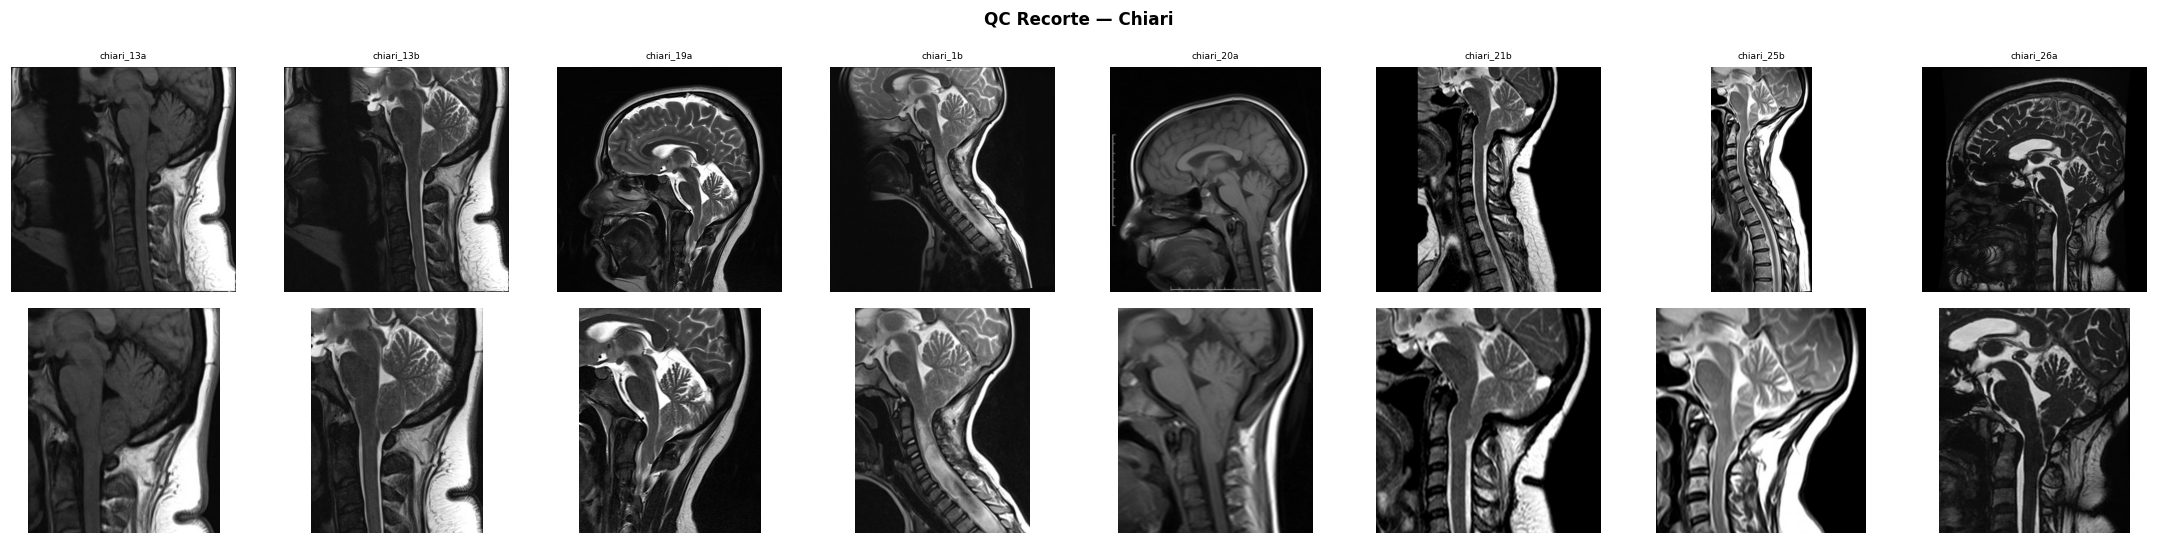

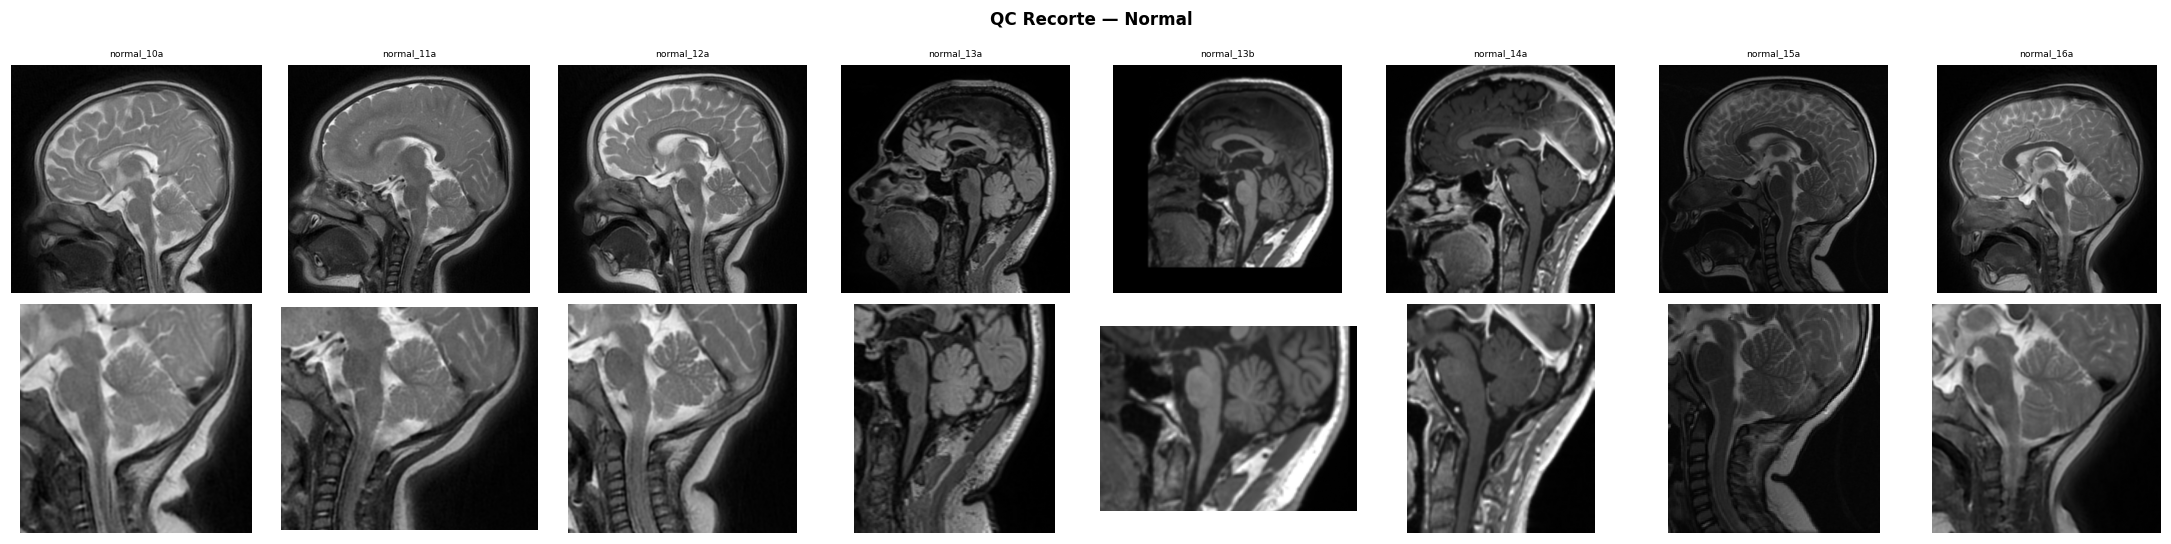

In [2]:
def qc_grid(imgs_src, imgs_dst, titulo, n=8):
    n = min(n, len(imgs_src))
    fig, axes = plt.subplots(2, n, figsize=(n*2.5, 5))
    fig.suptitle(titulo, fontsize=11, fontweight='bold')
    idx_dst = {p.name: p for p in imgs_dst}
    for col, src in enumerate(imgs_src[:n]):
        axes[0][col].imshow(np.array(Image.open(src).convert('L')), cmap='gray')
        axes[0][col].set_title(src.stem[:14], fontsize=6)
        axes[0][col].axis('off')
        dst = idx_dst.get(src.name)
        if dst and dst.exists():
            axes[1][col].imshow(np.array(Image.open(dst).convert('L')), cmap='gray')
        axes[1][col].axis('off')
    axes[0][0].set_ylabel('Original', fontsize=8)
    axes[1][0].set_ylabel('Recortada', fontsize=8)
    plt.tight_layout()
    plt.show()

qc_grid(listar(DIR_BAL_CH), listar(DIR_CRP_CH), 'QC Recorte — Chiari')
qc_grid(listar(DIR_BAL_NO), listar(DIR_CRP_NO), 'QC Recorte — Normal')

## 3. Preprocesamiento CLAHE y split train/val/test

Pipeline por imagen:
1. Clip percentil 1-99
2. Normalizacion [0, 255]
3. CLAHE (ecualiz. adaptativa, mejora contraste local de la fosa posterior)
4. Resize 224x224 con padding negro (preserva proporciones anatomicas)
5. QC de nitidez — varianza Laplaciano >= 80

In [3]:
QC_UMBRAL      = 80.0
AUGMENT_FACTOR = 5
SPLIT          = (0.70, 0.15, 0.15)

def normalizar_clahe(arr):
    s = arr.astype(np.float32)
    p1, p99 = np.percentile(s, [1, 99])
    s = np.clip(s, p1, p99)
    mn, mx = s.min(), s.max()
    if mx - mn < 1e-6:
        return None
    s = ((s - mn) / (mx - mn) * 255).astype(np.uint8)
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(s)

def calcular_nitidez(arr):
    return float(cv2.Laplacian(arr.astype(np.uint8), cv2.CV_64F).var())

def redimensionar(arr):
    img = Image.fromarray(arr)
    img.thumbnail(IMG_SIZE, Image.LANCZOS)
    fondo = Image.new('L', IMG_SIZE, 0)
    ox = (IMG_SIZE[0] - img.width)  // 2
    oy = (IMG_SIZE[1] - img.height) // 2
    fondo.paste(img, (ox, oy))
    return np.array(fondo)

def procesar(ruta):
    arr  = np.array(Image.open(ruta).convert('L'), dtype=np.float32)
    norm = normalizar_clahe(arr)
    if norm is None:
        return None, 'imagen_vacia'
    nit = calcular_nitidez(norm)
    if nit < QC_UMBRAL:
        return None, f'borrosa (nit={nit:.1f})'
    return redimensionar(norm), round(nit, 2)

validas, rechazadas = [], []
for clase, label in [('chiari', 1), ('normal', 0)]:
    carpeta = DIR_CRP_CH if clase == 'chiari' else DIR_CRP_NO
    for ruta in tqdm(listar(carpeta), desc=clase):
        arr, info = procesar(ruta)
        if arr is not None:
            validas.append({'ruta': str(ruta), 'nombre': ruta.name,
                            'clase': clase, 'label': label,
                            'nitidez': info, 'arr': arr})
        else:
            rechazadas.append({'nombre': ruta.name, 'clase': clase,
                               'motivo': info})

print(f'Validas    : {len(validas)}')
print(f'Rechazadas : {len(rechazadas)}')
if rechazadas:
    print(pd.DataFrame(rechazadas).to_string(index=False))

normal: 100%|██████████| 30/30 [00:00<00:00, 63.78it/s]

Validas    : 60
Rechazadas : 0


In [4]:
# Split estratificado
labels  = [v['label'] for v in validas]
indices = list(range(len(validas)))
TRAIN_R, VAL_R, TEST_R = SPLIT

idx_train, idx_temp = train_test_split(
    indices, test_size=(VAL_R + TEST_R), stratify=labels,
    random_state=SEED)
labels_temp = [labels[i] for i in idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp, test_size=TEST_R / (VAL_R + TEST_R),
    stratify=labels_temp, random_state=SEED)

splits_idx = {'train': idx_train, 'val': idx_val, 'test': idx_test}
print(f'  {"Split":<6} {"Chiari":>8} {"Normal":>8} {"Total":>8}')
print('  ' + '-'*32)
for sp, idxs in splits_idx.items():
    nc = sum(1 for i in idxs if validas[i]['label'] == 1)
    nn = sum(1 for i in idxs if validas[i]['label'] == 0)
    print(f'  {sp.upper():<6} {nc:>8} {nn:>8} {len(idxs):>8}')

  Split    Chiari   Normal    Total
  --------------------------------
  TRAIN        21       21       42
  VAL           5        4        9
  TEST          4        5        9


### Augmentation y guardado de data/processed/

In [ ]:
def augmentar(arr, seed=None):
    if seed is not None:
        random.seed(seed); np.random.seed(seed)
    img = arr.astype(np.float32) / 255.0
    H, W = img.shape
    if random.random() > 0.5:
        img = np.fliplr(img)
    if random.random() > 0.3:
        img = sk_transform.rotate(img, random.uniform(-10, 10),
                                  resize=False, mode='edge')
    if random.random() > 0.5:
        escala = random.uniform(0.92, 1.08)
        zoomed = sk_transform.rescale(img, escala, mode='edge',
                                      anti_aliasing=True)
        if escala > 1.0:
            d = (zoomed.shape[0] - H) // 2
            img = zoomed[d:d+H, d:d+W]
        else:
            pad = (H - zoomed.shape[0]) // 2
            img = np.pad(zoomed, pad, mode='constant')[:H, :W]
    if random.random() > 0.4:
        img = np.clip(img * random.uniform(0.90, 1.10)
                      + random.uniform(-0.08, 0.08), 0, 1)
    if random.random() > 0.6:
        img = np.clip(random_noise(img, mode='gaussian', var=0.001), 0, 1)
    return (img * 255).astype(np.uint8)

CLASES = ['chiari', 'normal']
registro_final = []

for split, idxs in splits_idx.items():
    for i in tqdm(idxs, desc=f'{split.upper():<6}'):
        item  = validas[i]
        arr   = item['arr']
        clase = item['clase']
        stem  = Path(item['ruta']).stem
        dst   = DIR_PROC / split / clase
        dst.mkdir(parents=True, exist_ok=True)

        out = dst / f'{stem}_proc.png'
        Image.fromarray(arr).save(str(out))
        registro_final.append({'archivo': out.name, 'clase': clase,
                                'label': item['label'], 'split': split,
                                'aumentada': False, 'nitidez': item['nitidez']})
        if split == 'train':
            for k in range(AUGMENT_FACTOR):
                seed_k  = (i * 100 + k + SEED) % 99991
                out_aug = dst / f'{stem}_aug{k:02d}.png'
                Image.fromarray(augmentar(arr, seed=seed_k)).save(str(out_aug))
                registro_final.append({'archivo': out_aug.name, 'clase': clase,
                                        'label': item['label'], 'split': split,
                                        'aumentada': True, 'nitidez': None})

df_proc = pd.DataFrame(registro_final)
df_proc.to_csv(DIR_REPORTS / 'inventario_procesado.csv', index=False)

print(f'{"="*52}')
print('  DATASET PROCESADO — RESUMEN')
print(f'{"="*52}')
for sp in ['train', 'val', 'test']:
    sub = df_proc[df_proc.split == sp]
    nc  = (sub.label == 1).sum()
    nn  = (sub.label == 0).sum()
    print(f'  {sp.upper():<6} {nc:>4} Chiari  {nn:>4} Normal  = {len(sub):>5}')
print(f'{"="*52}')
print(f'  TOTAL: {len(df_proc)} imagenes en data/processed/')

## 4. EDA — Estadisticas y t-SNE

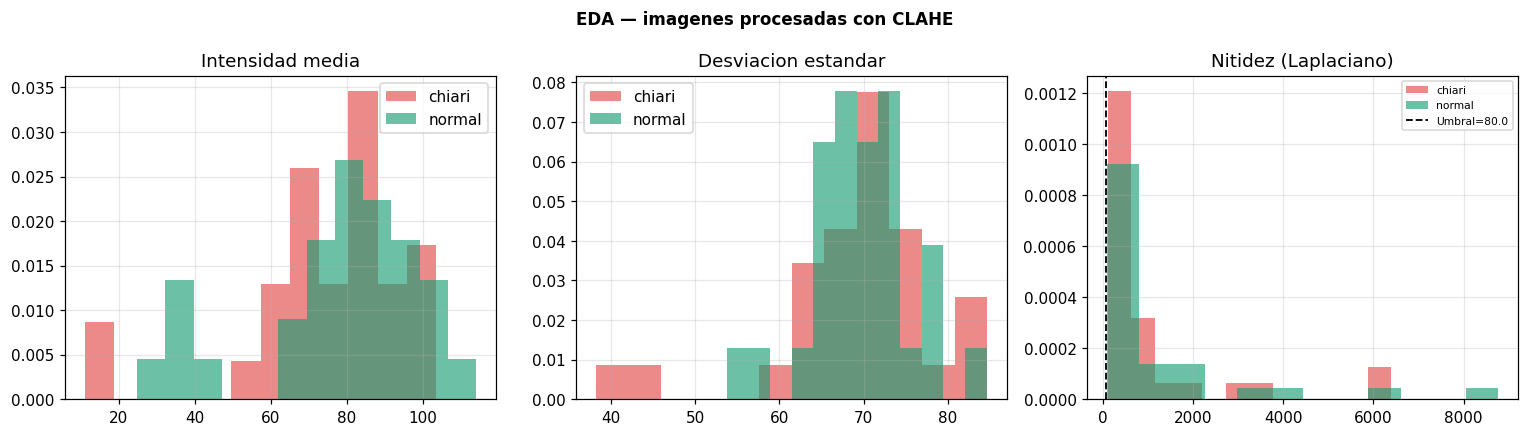

In [5]:
stats_cl = []
for item in validas:
    arr = item['arr']
    stats_cl.append({
        'clase'   : item['clase'],
        'nitidez' : item['nitidez'],
        'mean'    : float(arr.mean()),
        'std'     : float(arr.std()),
    })
df_cl = pd.DataFrame(stats_cl)

C = {'chiari': '#E24B4A', 'normal': '#1D9E75'}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('EDA — imagenes procesadas con CLAHE', fontsize=11, fontweight='bold')

for clase in ['chiari', 'normal']:
    sub = df_cl[df_cl.clase == clase]
    axes[0].hist(sub['mean'], bins=12, alpha=0.65, color=C[clase],
                 label=clase, density=True)
    axes[1].hist(sub['std'], bins=12, alpha=0.65, color=C[clase],
                 label=clase, density=True)
    axes[2].hist(sub['nitidez'], bins=12, alpha=0.65, color=C[clase],
                 label=clase, density=True)

axes[0].set_title('Intensidad media'); axes[0].legend()
axes[1].set_title('Desviacion estandar'); axes[1].legend()
axes[2].axvline(QC_UMBRAL, color='black', linestyle='--', lw=1.2,
                label=f'Umbral={QC_UMBRAL}')
axes[2].set_title('Nitidez (Laplaciano)'); axes[2].legend(fontsize=7)
for ax in axes: ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(DIR_FIGURES / 'eda_clahe.png'), dpi=150, bbox_inches='tight')
plt.show()

t-SNE sobre 60 imagenes × 4096 features (perp=10)...


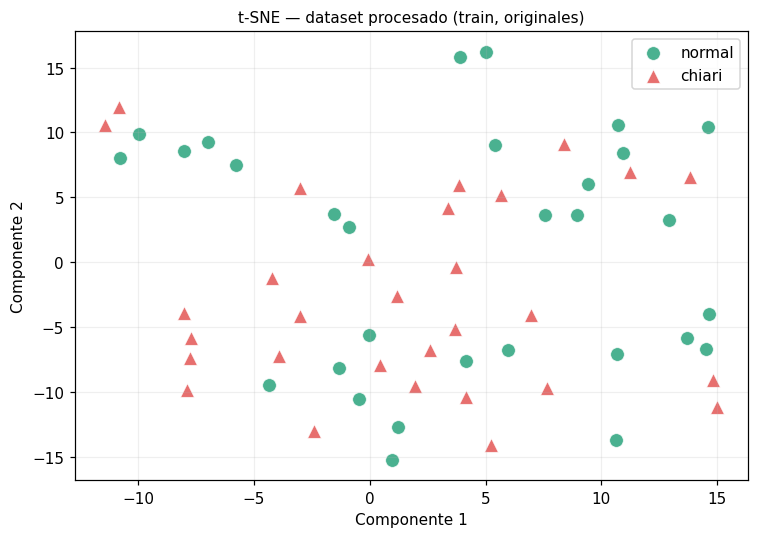

Guardado: reports/figures/tsne.png


In [9]:
# t-SNE — separabilidad de clases
TSNE_SZ = 64
X_list, y_list = [], []
for item in validas:
    arr = np.array(
        Image.fromarray(item['arr']).resize((TSNE_SZ, TSNE_SZ), Image.LANCZOS),
        dtype=np.float32
    ).flatten() / 255.0
    X_list.append(arr)
    y_list.append(item['label'])

X = StandardScaler().fit_transform(np.array(X_list))
y = np.array(y_list)

perp = min(10, len(X) // 3)
print(f't-SNE sobre {len(X)} imagenes × {X.shape[1]} features (perp={perp})...')
tsne = TSNE(n_components=2, perplexity=perp, max_iter=1000,
            random_state=SEED, verbose=0)
X2d = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for label, clase, marker in [(0, 'normal', 'o'), (1, 'chiari', '^')]:
    mask = y == label
    ax.scatter(X2d[mask, 0], X2d[mask, 1], c=C[clase], label=clase,
               alpha=0.8, marker=marker, s=80, edgecolors='white', lw=0.5)
ax.set_title('t-SNE — dataset procesado (train, originales)',
             fontsize=10)
ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(str(DIR_FIGURES / 'tsne.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: reports/figures/tsne.png')

## 5. Exportacion de configuracion para Notebook 03

In [8]:
n0 = sum(1 for v in validas if v['label'] == 0)
n1 = sum(1 for v in validas if v['label'] == 1)
tot = n0 + n1
nivel = 'BAJO' if n0/n1 <= 1.5 else 'MODERADO'

config = {
    'fecha'         : datetime.now().isoformat(),
    'n_total'       : tot,
    'n_normal'      : n0,
    'n_chiari'      : n1,
    'desbalance'    : nivel,
    'split'         : {sp: int(len(df_proc[df_proc.split == sp]))
                       for sp in ['train', 'val', 'test']},
    'imagen'        : {'size': list(IMG_SIZE), 'canales': 1},
    'augmentation'  : {'factor': AUGMENT_FACTOR, 'solo_train': True},
    'qc'            : {'umbral_nitidez': QC_UMBRAL,
                       'rechazadas': len(rechazadas)},
    'para_nb03'     : {'input_shape': [*IMG_SIZE, 1],
                       'batch_size': 8, 'epochs_max': 40, 'k_folds': 5},
}
with open(DIR_REPORTS / 'dataset_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('=' * 52)
print('  NOTEBOOK 02 COMPLETADO')
print('=' * 52)
print(f'  balanced/  : {N_POR_CLASE} Chiari + {N_POR_CLASE} Normal  (seed={SEED})')
print(f'  val_externo: {len(restantes_ch)} Chiari no usados')
print(f'  cropped/   : {len(listar(DIR_CRP_CH))} Ch + {len(listar(DIR_CRP_NO))} No')
print(f'  processed/ : {tot} imagenes  (train: x{AUGMENT_FACTOR} aug)')
print(f'  Rechazadas : {len(rechazadas)} (QC nitidez < {QC_UMBRAL})')
print()
print('  Siguiente: Notebook 03 — Entrenamiento CNN')
print('=' * 52)

NameError: name 'df_proc' is not defined